In [12]:
import redpitaya_control as rpc

In [17]:
rp = rpc.RedPitaya('169.254.240.122')

Connect to red pitaya. IP:169.254.240.122


In [18]:
data = rp.acquire_data_now()

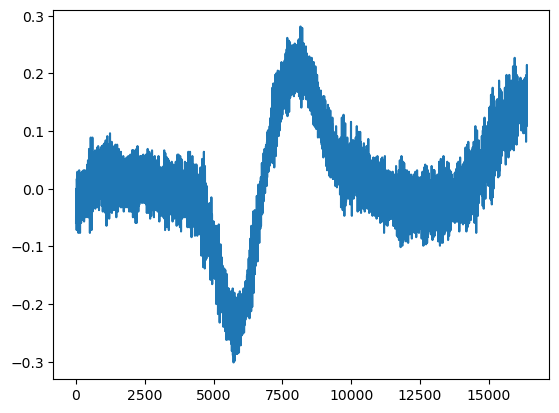

In [19]:
plt.plot(data)

In [20]:
rp.close()

Red Pitaya connection closed.


In [7]:
import time
import redpitaya_scpi as scpi
import matplotlib.pyplot as plt

In [6]:
rp = scpi.scpi('169.254.240.122')

In [9]:
rp.tx_txt('ACQ:RST')
rp.tx_txt('ACQ:DATA:FORMAT ASCII')
rp.tx_txt('ACQ:DATA:UNITS VOLTS')
rp.tx_txt('ACQ:DEC 8192')
rp.tx_txt('ACQ:SOUR1:GAIN HV')

rp.tx_txt('ACQ:TRIG:DLY 0')

rp.tx_txt('ACQ:START')
time.sleep(1)
rp.tx_txt('ACQ:TRIG NOW')
time.sleep(1)

while 1:
    rp.tx_txt('ACQ:TRIG:STAT?')
    if rp.rx_txt() == 'TD':
        break

rp.tx_txt('ACQ:SOUR1:DATA?')
buff_string = rp.rx_txt()
buff_string = buff_string.strip('{}\n\r').replace("  ", "").split(',')
buff = list(map(float, buff_string))

In [11]:
rp.close()